## **Imports**

In [11]:
#imports
import pandas as pd
import numpy as np
import pickle as pkl
import os
import time
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA




## **Loading Data**

In [12]:
#read \..\..Code\Merged_Data_Preprocessing\Resampled_Data_split\file_structure.pkl

data_path = "../../../../Merged_Data_Preprocessing/Resampled_Data_split"
with open(os.path.join(data_path, 'file_structure.pkl'), 'rb') as f:
    file_structure = pkl.load(f)


#display file structure
file_structure

{'original': {'X_path': 'Resampled_Data_split\\original\\X_original.parquet',
  'y_path': 'Resampled_Data_split\\original\\y_original.pkl'},
 'smote': {'X_path': 'Resampled_Data_split\\smote\\X_smote.parquet',
  'y_path': 'Resampled_Data_split\\smote\\y_smote.pkl'},
 'tomek': {'X_path': 'Resampled_Data_split\\tomek\\X_tomek.parquet',
  'y_path': 'Resampled_Data_split\\tomek\\y_tomek.pkl'},
 'smote_tomek': {'X_path': 'Resampled_Data_split\\smote_tomek\\X_smote_tomek.parquet',
  'y_path': 'Resampled_Data_split\\smote_tomek\\y_smote_tomek.pkl'},
 'test': {'X_path': 'Resampled_Data_split\\test\\X_test.parquet',
  'y_path': 'Resampled_Data_split\\test\\y_test.pkl'},
 'val': {'X_path': 'Resampled_Data_split\\val\\X_val.parquet',
  'y_path': 'Resampled_Data_split\\val\\y_val.pkl'}}

In [13]:
y_train = pd.read_pickle(f'{data_path}/original/y_original.pkl')
y_test = pd.read_pickle(f'{data_path}/test/y_test.pkl')
y_val = pd.read_pickle(f'{data_path}/val/y_val.pkl')

In [14]:
X_test = pd.read_parquet(f'{data_path}/test/X_test.parquet')
X_val = pd.read_parquet(f'{data_path}/val/X_val.parquet')


In [15]:
#loading original no resampled X_train, y_train, X_test, y_test, X_val, y_val parquet files
normalized_path = '../../../../Merged_Data_Preprocessing/Normalized_Data_split'
X_train = pd.read_parquet(f'{normalized_path}/X_train_original.parquet')


In [16]:

# Convert boolean columns to int
bool_cols = X_train.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    print(f"Converting {len(bool_cols)} boolean columns to int...")
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols] = X_test[bool_cols].astype(int)
    X_val[bool_cols] = X_val[bool_cols].astype(int)
    print("Conversion complete!")

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Converting 7 boolean columns to int...
Conversion complete!
X_train shape: (16226, 64)
y_train shape: (16226,)


## **DB Scan from Scratch**

In [17]:
class DBSCANFromScratch:
    def __init__(self, eps=0.5, min_samples=5):
        """
        DBSCAN clustering from scratch (optimized with vectorization)
        
        Parameters:
        -----------
        eps : float
            Maximum distance between two samples for one to be considered in the neighborhood
        min_samples : int
            Minimum number of samples in a neighborhood for a point to be core
        """
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
        self.core_sample_indices_ = None
        self.n_clusters_ = 0
        
    def _compute_distance_matrix(self, X):
        """
        Compute pairwise distance matrix efficiently using vectorization
        Returns: (n_samples, n_samples) distance matrix
        """
        # ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a*b
        sum_X = np.sum(X ** 2, axis=1, keepdims=True)
        distances = sum_X + sum_X.T - 2 * np.dot(X, X.T)
        distances = np.sqrt(np.maximum(distances, 0))  # Avoid negative values due to numerical errors
        return distances
    
    def _get_neighbors_vectorized(self, distance_matrix, point_idx):
        """Find all neighbors within eps distance using precomputed distances"""
        neighbors = np.where(distance_matrix[point_idx] <= self.eps)[0].tolist()
        return neighbors
    
    def fit(self, X):
        """
        Fit DBSCAN to data
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        """
        # Convert to numpy array
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float64)
        else:
            X = np.asarray(X, dtype=np.float64)
        
        n_samples = X.shape[0]
        
        print("Computing distance matrix...")
        # Precompute all pairwise distances (vectorized)
        distance_matrix = self._compute_distance_matrix(X)
        
        # Initialize all points as unvisited (0)
        # -1 will be noise, positive integers will be cluster IDs
        labels = np.zeros(n_samples, dtype=int)
        
        cluster_id = 0
        core_samples = []
        
        # Visit each point
        for point_idx in range(n_samples):
            if point_idx % 1000 == 0:
                print(f"Processing point {point_idx}/{n_samples}...")
            
            # Skip if already processed
            if labels[point_idx] != 0:
                continue
            
            # Find neighbors using precomputed distances
            neighbors = self._get_neighbors_vectorized(distance_matrix, point_idx)
            
            # Check if core point
            if len(neighbors) < self.min_samples:
                # Mark as noise
                labels[point_idx] = -1
            else:
                # Core point found, start new cluster
                cluster_id += 1
                core_samples.append(point_idx)
                self._expand_cluster(labels, point_idx, neighbors, cluster_id, distance_matrix)
        
        self.labels_ = labels
        self.core_sample_indices_ = np.array(core_samples)
        self.n_clusters_ = cluster_id
        
        return self
    
    def _expand_cluster(self, labels, point_idx, neighbors, cluster_id, distance_matrix):
        """Expand cluster from a core point"""
        labels[point_idx] = cluster_id
        
        i = 0
        while i < len(neighbors):
            neighbor_idx = neighbors[i]
            
            # If neighbor is noise, add to current cluster
            if labels[neighbor_idx] == -1:
                labels[neighbor_idx] = cluster_id
            
            # If neighbor is unvisited
            elif labels[neighbor_idx] == 0:
                labels[neighbor_idx] = cluster_id
                
                # Find neighbors of this neighbor using precomputed distances
                neighbor_neighbors = self._get_neighbors_vectorized(distance_matrix, neighbor_idx)
                
                # If neighbor is also a core point, expand from it
                if len(neighbor_neighbors) >= self.min_samples:
                    neighbors.extend(neighbor_neighbors)
            
            i += 1
    
    def fit_predict(self, X):
        """Fit and predict in one step"""
        self.fit(X)
        return self.labels_


print("Optimized DBSCAN class implementation complete!")

Optimized DBSCAN class implementation complete!


## **Training DBSCAN**

In [18]:
# Train DBSCAN from scratch
print("Training DBSCAN from scratch...")
print(f"X_train shape: {X_train.shape}")
print("="*60)

from sklearn.decomposition import PCA
pca = PCA(n_components=8, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train)

print("Explained variance ratio (sum):", pca.explained_variance_ratio_.sum())
    
# Use eps=40 (75th percentile from k-distance graph) as starting point
start_time = time.time()
dbscan = DBSCANFromScratch(eps=0.8207, min_samples=40)
dbscan.fit(X_train_pca)
runtime = time.time() - start_time

labels = dbscan.labels_
n_noise = np.sum(labels == -1)
noise_ratio = n_noise / len(labels)

print("Training complete!")
print(f"Runtime: {runtime:.2f} seconds")
print(f"Number of clusters: {dbscan.n_clusters_}")
print(f"Noise points: {n_noise} ({noise_ratio:.2%})")


Training DBSCAN from scratch...
X_train shape: (16226, 64)
Explained variance ratio (sum): 0.9999953818912435
Computing distance matrix...
Processing point 0/16226...
Processing point 1000/16226...
Processing point 2000/16226...
Processing point 3000/16226...
Processing point 4000/16226...
Processing point 5000/16226...
Processing point 6000/16226...
Processing point 7000/16226...
Processing point 8000/16226...
Processing point 9000/16226...
Processing point 10000/16226...
Processing point 11000/16226...
Processing point 12000/16226...
Processing point 13000/16226...
Processing point 14000/16226...
Processing point 15000/16226...
Processing point 16000/16226...
Training complete!
Runtime: 10.14 seconds
Number of clusters: 11
Noise points: 1495 (9.21%)


In [19]:
# Metrics computation
def compute_dbscan_metrics(X, labels, y_true=None):
    metrics = {}
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    metrics['n_clusters'] = n_clusters
    metrics['n_noise'] = int(np.sum(labels == -1))
    metrics['noise_ratio'] = metrics['n_noise'] / len(labels)

    # Internal metrics (exclude noise)
    mask = labels != -1
    if n_clusters > 0 and np.sum(mask) > 1:
        X_f = X.values if isinstance(X, pd.DataFrame) else X
        X_f = X_f.astype(float)
        X_non_noise = X_f[mask]
        labels_non_noise = labels[mask]
        if len(np.unique(labels_non_noise)) > 1:
            metrics['silhouette'] = silhouette_score(X_non_noise, labels_non_noise)
            metrics['davies_bouldin'] = davies_bouldin_score(X_non_noise, labels_non_noise)
            metrics['calinski_harabasz'] = calinski_harabasz_score(X_non_noise, labels_non_noise)
        else:
            metrics['silhouette'] = None
            metrics['davies_bouldin'] = None
            metrics['calinski_harabasz'] = None
    else:
        metrics['silhouette'] = None
        metrics['davies_bouldin'] = None
        metrics['calinski_harabasz'] = None

    # External metrics
    if y_true is not None:
        y_arr = np.asarray(y_true).ravel()
        metrics['ami'] = adjusted_mutual_info_score(y_arr, labels)
        metrics['ari'] = adjusted_rand_score(y_arr, labels)
        fire_rates = {}
        for cid in set(labels):
            m = labels == cid
            if np.sum(m) > 0:
                fire_rates[cid] = float(np.mean(y_arr[m]))
        metrics['fire_rates'] = fire_rates
    return metrics

metrics = compute_dbscan_metrics(X_train, labels, y_train)

print("="*60)
print("DBSCAN METRICS")
print("="*60)
print(f"Number of clusters: {metrics['n_clusters']}")
print(f"Noise points: {metrics['n_noise']} ({metrics['noise_ratio']:.2%})")
print(f"Silhouette Score: {metrics['silhouette'] if metrics['silhouette'] is not None else 'N/A'}")
print(f"Davies-Bouldin Index: {metrics['davies_bouldin'] if metrics['davies_bouldin'] is not None else 'N/A'}")
print(f"Calinski-Harabasz Index: {metrics['calinski_harabasz'] if metrics['calinski_harabasz'] is not None else 'N/A'}")
print(f"AMI: {metrics.get('ami', 'N/A')}")
print(f"ARI: {metrics.get('ari', 'N/A')}")

DBSCAN METRICS
Number of clusters: 11
Noise points: 1495 (9.21%)
Silhouette Score: -0.22684690801758484
Davies-Bouldin Index: 2.3343571668555616
Calinski-Harabasz Index: 199812.16425774415
AMI: 0.04143125122032405
ARI: 0.021979481161104215


In [20]:

# Predict on validation set
print("="*60)
print("PREDICTING ON VALIDATION SET")
print("="*60)

# Transform validation data using same PCA
X_val_pca = pca.transform(X_val)
val_labels = dbscan.fit_predict(X_val_pca)

# Compute metrics for validation set
val_metrics = compute_dbscan_metrics(X_val, val_labels, y_val)

print(f"Number of clusters: {val_metrics['n_clusters']}")
print(f"Noise points: {val_metrics['n_noise']} ({val_metrics['noise_ratio']:.2%})")
print(f"Silhouette Score: {val_metrics['silhouette'] if val_metrics['silhouette'] is not None else 'N/A'}")
print(f"Davies-Bouldin Index: {val_metrics['davies_bouldin'] if val_metrics['davies_bouldin'] is not None else 'N/A'}")
print(f"Calinski-Harabasz Index: {val_metrics['calinski_harabasz'] if val_metrics['calinski_harabasz'] is not None else 'N/A'}")
print(f"AMI: {val_metrics.get('ami', 'N/A')}")
print(f"ARI: {val_metrics.get('ari', 'N/A')}")

# Validation contingency table
val_contingency = pd.crosstab(val_labels, y_val, rownames=['Cluster'], colnames=['Fire'], margins=True)
val_contingency.index = ['Noise' if idx == -1 else f'Cluster {idx}' for idx in val_contingency.index[:-1]] + ['Total']
val_contingency.columns = ['No Fire', 'Fire', 'Total']
print("\nValidation Contingency Table (counts):\n", val_contingency)

val_contingency_pct = pd.crosstab(val_labels, y_val, rownames=['Cluster'], colnames=['Fire'], normalize='index') * 100
val_contingency_pct.index = ['Noise' if idx == -1 else f'Cluster {idx}' for idx in val_contingency_pct.index]
val_contingency_pct.columns = ['No Fire %', 'Fire %']
print("\nValidation Contingency Table (percentages):\n", val_contingency_pct)


PREDICTING ON VALIDATION SET
Computing distance matrix...
Processing point 0/3477...
Processing point 1000/3477...
Processing point 2000/3477...
Processing point 3000/3477...
Number of clusters: 6
Noise points: 771 (22.17%)
Silhouette Score: -0.18109450419417245
Davies-Bouldin Index: 5.792840642727177
Calinski-Harabasz Index: 931.1915471091373
AMI: 0.029307707918383965
ARI: -0.0013789230847651448

Validation Contingency Table (counts):
            No Fire  Fire  Total
Noise          644   127    771
Cluster 1      530    19    549
Cluster 2      441    19    460
Cluster 3      629     1    630
Cluster 4      863    33    896
Cluster 5      127     2    129
Cluster 6       42     0     42
Total         3276   201   3477

Validation Contingency Table (percentages):
             No Fire %     Fire %
Noise       83.527886  16.472114
Cluster 1   96.539162   3.460838
Cluster 2   95.869565   4.130435
Cluster 3   99.841270   0.158730
Cluster 4   96.316964   3.683036
Cluster 5   98.449612   1.5

In [21]:

# Predict on test set
print("\n" + "="*60)
print("PREDICTING ON TEST SET")
print("="*60)

# Transform test data using same PCA
X_test_pca = pca.transform(X_test)
test_labels = dbscan.fit_predict(X_test_pca)

# Compute metrics for test set
test_metrics = compute_dbscan_metrics(X_test, test_labels, y_test)

print(f"Number of clusters: {test_metrics['n_clusters']}")
print(f"Noise points: {test_metrics['n_noise']} ({test_metrics['noise_ratio']:.2%})")
print(f"Silhouette Score: {test_metrics['silhouette'] if test_metrics['silhouette'] is not None else 'N/A'}")
print(f"Davies-Bouldin Index: {test_metrics['davies_bouldin'] if test_metrics['davies_bouldin'] is not None else 'N/A'}")
print(f"Calinski-Harabasz Index: {test_metrics['calinski_harabasz'] if test_metrics['calinski_harabasz'] is not None else 'N/A'}")
print(f"AMI: {test_metrics.get('ami', 'N/A')}")
print(f"ARI: {test_metrics.get('ari', 'N/A')}")

# Test contingency table
test_contingency = pd.crosstab(test_labels, y_test, rownames=['Cluster'], colnames=['Fire'], margins=True)
test_contingency.index = ['Noise' if idx == -1 else f'Cluster {idx}' for idx in test_contingency.index[:-1]] + ['Total']
test_contingency.columns = ['No Fire', 'Fire', 'Total']
print("\nTest Contingency Table (counts):\n", test_contingency)

test_contingency_pct = pd.crosstab(test_labels, y_test, rownames=['Cluster'], colnames=['Fire'], normalize='index') * 100
test_contingency_pct.index = ['Noise' if idx == -1 else f'Cluster {idx}' for idx in test_contingency_pct.index]
test_contingency_pct.columns = ['No Fire %', 'Fire %']
print("\nTest Contingency Table (percentages):\n", test_contingency_pct)



PREDICTING ON TEST SET
Computing distance matrix...
Processing point 0/3477...
Processing point 1000/3477...
Processing point 2000/3477...
Processing point 3000/3477...
Number of clusters: 5
Noise points: 781 (22.46%)
Silhouette Score: -0.0038229554534181267
Davies-Bouldin Index: 4.42609741039714
Calinski-Harabasz Index: 1133.3157670672304
AMI: 0.03345818379273557
ARI: 0.00539242744737947

Test Contingency Table (counts):
            No Fire  Fire  Total
Noise          652   129    781
Cluster 1      496    19    515
Cluster 2     1341    51   1392
Cluster 3      592     2    594
Cluster 4      147     1    148
Cluster 5       47     0     47
Total         3275   202   3477

Test Contingency Table (percentages):
             No Fire %     Fire %
Noise       83.482714  16.517286
Cluster 1   96.310680   3.689320
Cluster 2   96.336207   3.663793
Cluster 3   99.663300   0.336700
Cluster 4   99.324324   0.675676
Cluster 5  100.000000   0.000000


In [22]:

# Comprehensive metrics summary
print("\n" + "="*80)
print("COMPREHENSIVE DBSCAN METRICS SUMMARY")
print("="*80)

metrics_summary = pd.DataFrame({
    'Metric': [
        'Number of Clusters',
        'Noise Points',
        'Noise Ratio (%)',
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Calinski-Harabasz Index',
        'AMI',
        'ARI'
    ],
    'Training': [
        metrics['n_clusters'],
        metrics['n_noise'],
        f"{metrics['noise_ratio']:.2%}",
        f"{metrics['silhouette']:.4f}" if metrics['silhouette'] is not None else 'N/A',
        f"{metrics['davies_bouldin']:.4f}" if metrics['davies_bouldin'] is not None else 'N/A',
        f"{metrics['calinski_harabasz']:.4f}" if metrics['calinski_harabasz'] is not None else 'N/A',
        f"{metrics.get('ami', 'N/A'):.4f}" if isinstance(metrics.get('ami', 'N/A'), float) else 'N/A',
        f"{metrics.get('ari', 'N/A'):.4f}" if isinstance(metrics.get('ari', 'N/A'), float) else 'N/A'
    ],
    'Validation': [
        val_metrics['n_clusters'],
        val_metrics['n_noise'],
        f"{val_metrics['noise_ratio']:.2%}",
        f"{val_metrics['silhouette']:.4f}" if val_metrics['silhouette'] is not None else 'N/A',
        f"{val_metrics['davies_bouldin']:.4f}" if val_metrics['davies_bouldin'] is not None else 'N/A',
        f"{val_metrics['calinski_harabasz']:.4f}" if val_metrics['calinski_harabasz'] is not None else 'N/A',
        f"{val_metrics.get('ami', 'N/A'):.4f}" if isinstance(val_metrics.get('ami', 'N/A'), float) else 'N/A',
        f"{val_metrics.get('ari', 'N/A'):.4f}" if isinstance(val_metrics.get('ari', 'N/A'), float) else 'N/A'
    ],
    'Test': [
        test_metrics['n_clusters'],
        test_metrics['n_noise'],
        f"{test_metrics['noise_ratio']:.2%}",
        f"{test_metrics['silhouette']:.4f}" if test_metrics['silhouette'] is not None else 'N/A',
        f"{test_metrics['davies_bouldin']:.4f}" if test_metrics['davies_bouldin'] is not None else 'N/A',
        f"{test_metrics['calinski_harabasz']:.4f}" if test_metrics['calinski_harabasz'] is not None else 'N/A',
        f"{test_metrics.get('ami', 'N/A'):.4f}" if isinstance(test_metrics.get('ami', 'N/A'), float) else 'N/A',
        f"{test_metrics.get('ari', 'N/A'):.4f}" if isinstance(test_metrics.get('ari', 'N/A'), float) else 'N/A'
    ]
})

print("\n", metrics_summary.to_string(index=False))
print("\n" + "="*80)

# Fire rates comparison
print("\nFIRE RATES BY CLUSTER:")
print("-" * 80)

fire_rates_data = []
all_cluster_ids = sorted(set(labels) | set(val_labels) | set(test_labels))

for cid in all_cluster_ids:
    cluster_name = 'Noise' if cid == -1 else f'Cluster {cid}'
    
    train_rate = metrics['fire_rates'].get(cid, 0) * 100 if 'fire_rates' in metrics else 0
    val_rate = val_metrics['fire_rates'].get(cid, 0) * 100 if 'fire_rates' in val_metrics else 0
    test_rate = test_metrics['fire_rates'].get(cid, 0) * 100 if 'fire_rates' in test_metrics else 0
    
    fire_rates_data.append({
        'Cluster': cluster_name,
        'Train Fire Rate (%)': f"{train_rate:.2f}",
        'Val Fire Rate (%)': f"{val_rate:.2f}",
        'Test Fire Rate (%)': f"{test_rate:.2f}"
    })

fire_rates_df = pd.DataFrame(fire_rates_data)
print(fire_rates_df.to_string(index=False))
print("-" * 80)

# Overall fire rates
print(f"\nOverall Fire Rates:")
print(f"  Training: {np.mean(y_train)*100:.2f}%")
print(f"  Validation: {np.mean(y_val)*100:.2f}%")
print(f"  Test: {np.mean(y_test)*100:.2f}%")



COMPREHENSIVE DBSCAN METRICS SUMMARY

                  Metric    Training Validation      Test
     Number of Clusters          11          6         5
           Noise Points        1495        771       781
        Noise Ratio (%)       9.21%     22.17%    22.46%
       Silhouette Score     -0.2268    -0.1811   -0.0038
   Davies-Bouldin Index      2.3344     5.7928    4.4261
Calinski-Harabasz Index 199812.1643   931.1915 1133.3158
                    AMI      0.0414     0.0293    0.0335
                    ARI      0.0220    -0.0014    0.0054


FIRE RATES BY CLUSTER:
--------------------------------------------------------------------------------
   Cluster Train Fire Rate (%) Val Fire Rate (%) Test Fire Rate (%)
     Noise               29.03             16.47              16.52
 Cluster 1                4.28              3.46               3.69
 Cluster 2                0.39              4.13               3.66
 Cluster 3                1.32              0.16               0.34
 

In [24]:

# Create contingency table for training set (for visualization)
contingency = pd.crosstab(labels, y_train, rownames=['Cluster'], colnames=['Fire'], margins=True)
contingency.index = ['Noise' if idx == -1 else f'Cluster {idx}' for idx in contingency.index[:-1]] + ['Total']
contingency.columns = ['No Fire', 'Fire', 'Total']


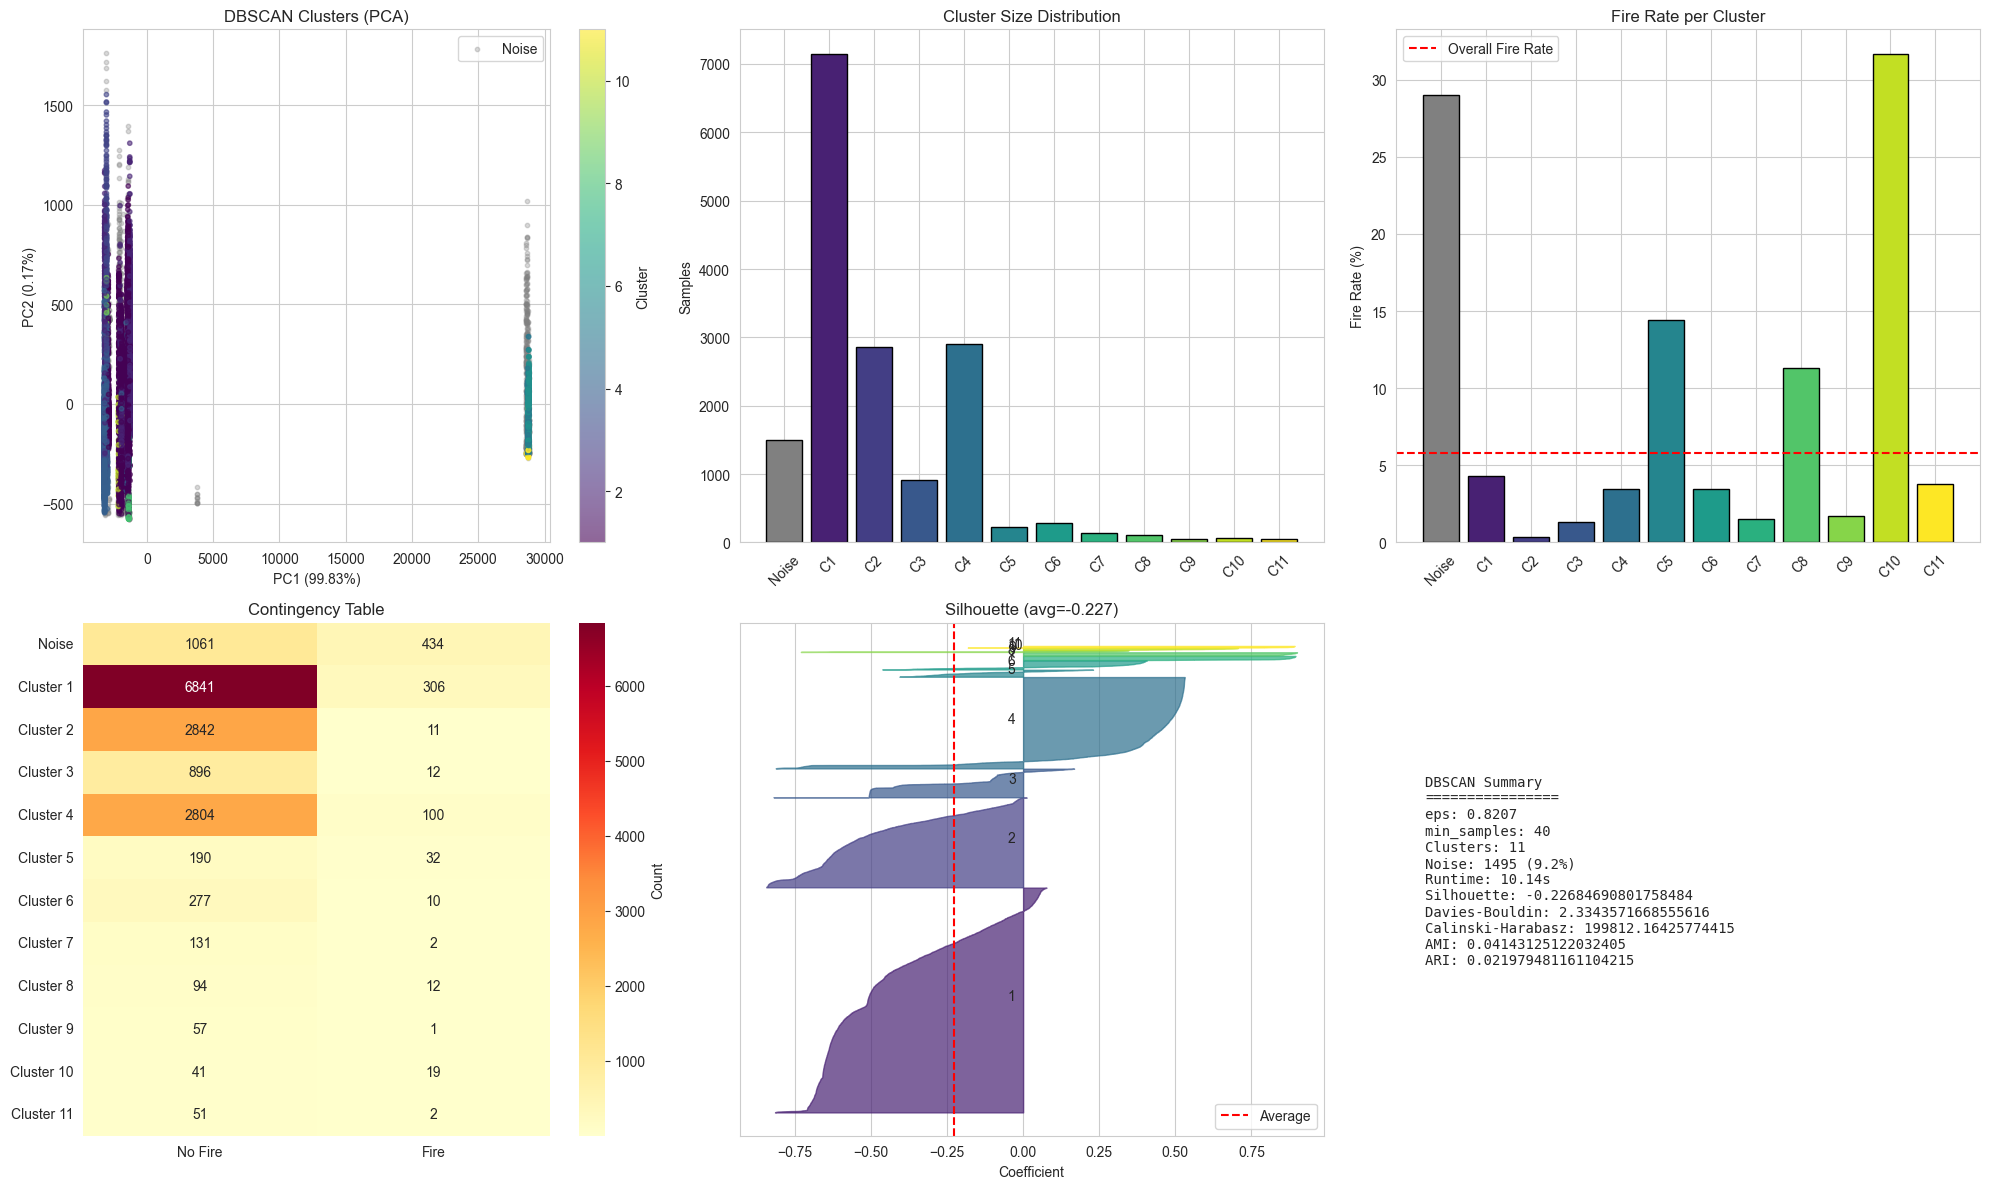

Visualization complete!


In [27]:
# Visualizations
sns.set_style("whitegrid")
pca = PCA(n_components=8)
X_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
X_pca = pca.fit_transform(X_np)
mask_noise = labels == -1
mask_clustered = labels != -1
unique_labels = sorted(set(labels))

fig = plt.figure(figsize=(20, 12))

# 1. PCA scatter
ax1 = plt.subplot(2, 3, 1)
if np.any(mask_noise):
    ax1.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1], c='gray', s=10, alpha=0.3, label='Noise')
if np.any(mask_clustered):
    sc = ax1.scatter(X_pca[mask_clustered, 0], X_pca[mask_clustered, 1], c=labels[mask_clustered], cmap='viridis', s=10, alpha=0.6)
    plt.colorbar(sc, ax=ax1, label='Cluster')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax1.set_title('DBSCAN Clusters (PCA)')
ax1.legend()

# 2. Cluster size distribution
ax2 = plt.subplot(2, 3, 2)
cluster_sizes = [np.sum(labels == l) for l in unique_labels]
cluster_names = ['Noise' if l == -1 else f'C{l}' for l in unique_labels]
colors = ['gray' if l == -1 else plt.cm.viridis(l / max(unique_labels if max(unique_labels)!=0 else [1])) for l in unique_labels]
ax2.bar(cluster_names, cluster_sizes, color=colors, edgecolor='black')
ax2.set_title('Cluster Size Distribution')
ax2.set_ylabel('Samples')
ax2.tick_params(axis='x', rotation=45)

# 3. Fire rate per cluster
ax3 = plt.subplot(2, 3, 3)
fire_rates = [metrics['fire_rates'].get(l, 0) * 100 for l in unique_labels] if 'fire_rates' in metrics else [0]*len(unique_labels)
ax3.bar(cluster_names, fire_rates, color=colors, edgecolor='black')
ax3.axhline(np.mean(y_train)*100, color='red', linestyle='--', label='Overall Fire Rate')
ax3.set_ylabel('Fire Rate (%)')
ax3.set_title('Fire Rate per Cluster')
ax3.tick_params(axis='x', rotation=45)
ax3.legend()

# 4. Contingency heatmap
ax4 = plt.subplot(2, 3, 4)
cont_matrix = contingency.iloc[:-1, :-1].values
sns.heatmap(cont_matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['No Fire', 'Fire'], yticklabels=contingency.index[:-1], ax=ax4, cbar_kws={'label': 'Count'})
ax4.set_title('Contingency Table')

# 5. Silhouette plot (if applicable)
ax5 = plt.subplot(2, 3, 5)
if metrics['silhouette'] is not None and np.any(mask_clustered):
    from sklearn.metrics import silhouette_samples
    sil_vals = silhouette_samples(X_np[mask_clustered], labels[mask_clustered])
    y_lower = 10
    for cid in sorted(set(labels[mask_clustered])):
        sv = sil_vals[labels[mask_clustered] == cid]
        sv.sort()
        size = sv.shape[0]
        y_upper = y_lower + size
        color = plt.cm.viridis(float(cid) / max(unique_labels if max(unique_labels)!=0 else [1]))
        ax5.fill_betweenx(np.arange(y_lower, y_upper), 0, sv, facecolor=color, edgecolor=color, alpha=0.7)
        ax5.text(-0.05, y_lower + 0.5*size, str(cid))
        y_lower = y_upper + 10
    ax5.axvline(metrics['silhouette'], color='red', linestyle='--', label='Average')
    ax5.set_title(f"Silhouette (avg={metrics['silhouette']:.3f})")
    ax5.set_xlabel('Coefficient')
    ax5.set_yticks([])
    ax5.legend()
else:
    ax5.text(0.5, 0.5, 'Silhouette N/A', ha='center', va='center', transform=ax5.transAxes)
    ax5.axis('off')

# 6. Metrics summary
ax6 = plt.subplot(2, 3, 6)
summary = (
    f"DBSCAN Summary\n"
    f"{'=' * 16}\n"
    f"eps: {dbscan.eps}\n"
    f"min_samples: {dbscan.min_samples}\n"
    f"Clusters: {metrics['n_clusters']}\n"
    f"Noise: {metrics['n_noise']} ({metrics['noise_ratio']:.1%})\n"
    f"Runtime: {runtime:.2f}s\n"
    f"Silhouette: {metrics['silhouette'] if metrics['silhouette'] is not None else 'N/A'}\n"
    f"Davies-Bouldin: {metrics['davies_bouldin'] if metrics['davies_bouldin'] is not None else 'N/A'}\n"
    f"Calinski-Harabasz: {metrics['calinski_harabasz'] if metrics['calinski_harabasz'] is not None else 'N/A'}\n"
    f"AMI: {metrics.get('ami', 'N/A')}\n"
    f"ARI: {metrics.get('ari', 'N/A')}\n"
)
ax6.text(0.05, 0.5, summary, family='monospace', va='center')
ax6.axis('off')

plt.tight_layout()
plt.savefig('../../../../../Rapport_TP/images/DBscan/dbscan_from_scratch_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visualization complete!")

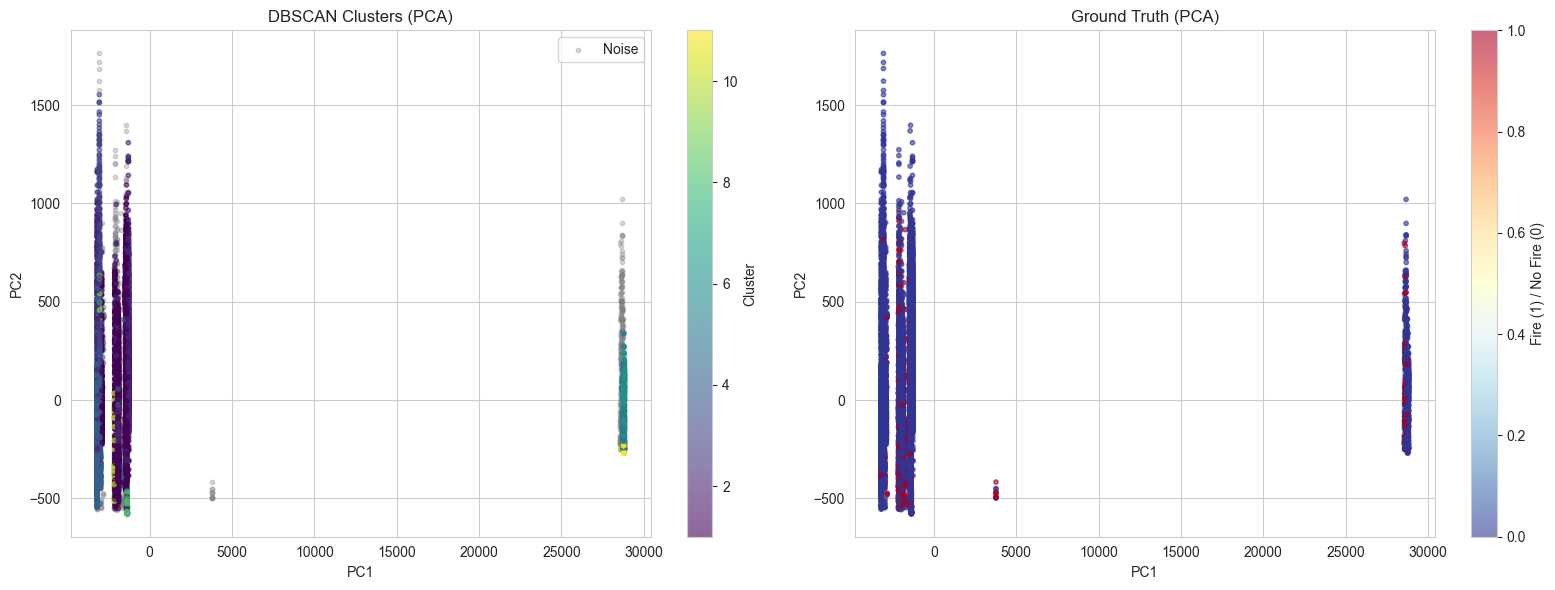

In [28]:
# PCA colored by clusters vs ground truth
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1], c='gray', s=10, alpha=0.3, label='Noise') if np.any(mask_noise) else None
if np.any(mask_clustered):
    sc1 = axes[0].scatter(X_pca[mask_clustered, 0], X_pca[mask_clustered, 1], c=labels[mask_clustered], cmap='viridis', s=10, alpha=0.6)
    plt.colorbar(sc1, ax=axes[0], label='Cluster')
axes[0].set_title('DBSCAN Clusters (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='RdYlBu_r', s=10, alpha=0.6)
plt.colorbar(sc2, ax=axes[1], label='Fire (1) / No Fire (0)')
axes[1].set_title('Ground Truth (PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('../../../../../Rapport_TP/images/DBscan/dbscan_pca_ground_truth_from_scratch.png', dpi=300, bbox_inches='tight')
plt.show()